In [1]:
print("Notebook Working")


Notebook Working


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

# ----------------------------
# LOAD DATASETS
# ----------------------------

fund_master = pd.read_csv(
    "../data/processed/cleaned_01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/cleaned_nav_history.csv"
)

aum = pd.read_csv(
    "../data/processed/cleaned_03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/processed/cleaned_04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/processed/cleaned_05_category_inflows.csv"
)

folios = pd.read_csv(
    "../data/processed/cleaned_06_industry_folio_count.csv"
)

performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

transactions = pd.read_csv(
    "../data/processed/cleaned_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/processed/cleaned_09_portfolio_holdings.csv"
)

# ----------------------------
# CONVERT DATES
# ----------------------------

nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print(nav.shape)

print(aum.shape)

print(sip.shape)

print(transactions.shape)

(46000, 3)
(90, 5)
(48, 6)
(32778, 13)


In [4]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022-2026)"
)

fig.show()

In [5]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends with Market Events"
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    opacity=0.2
)

# 2024 Correction
fig.add_vrect(
    x0="2024-06-01",
    x1="2024-10-01",
    annotation_text="2024 Correction",
    opacity=0.2
)

fig.show()

In [6]:
fig.write_image(
    "../reports/chart_01_nav_trend.png"
)

print("Chart saved successfully!")

Chart saved successfully!


# Insight 1

All 40 mutual fund schemes showed an overall upward NAV trend from 2022–2025, reflecting strong long-term growth despite temporary market corrections.

(Refer Chart 01)

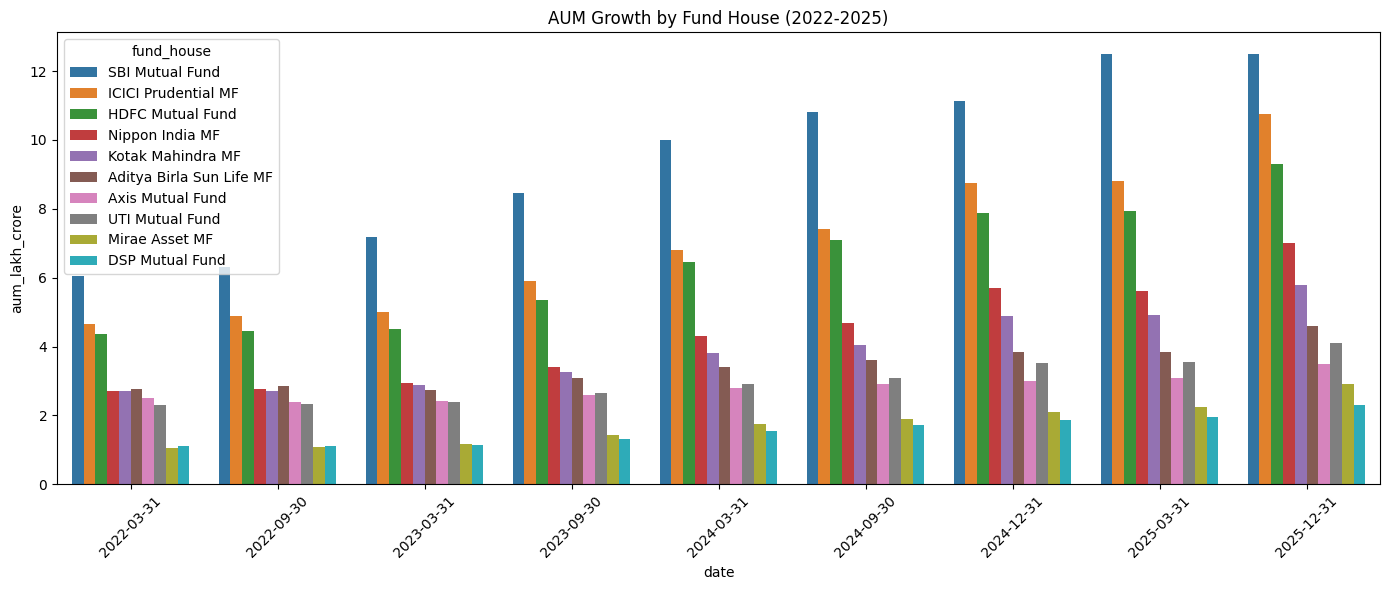

In [7]:
# Convert date

aum["date"] = pd.to_datetime(aum["date"])

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

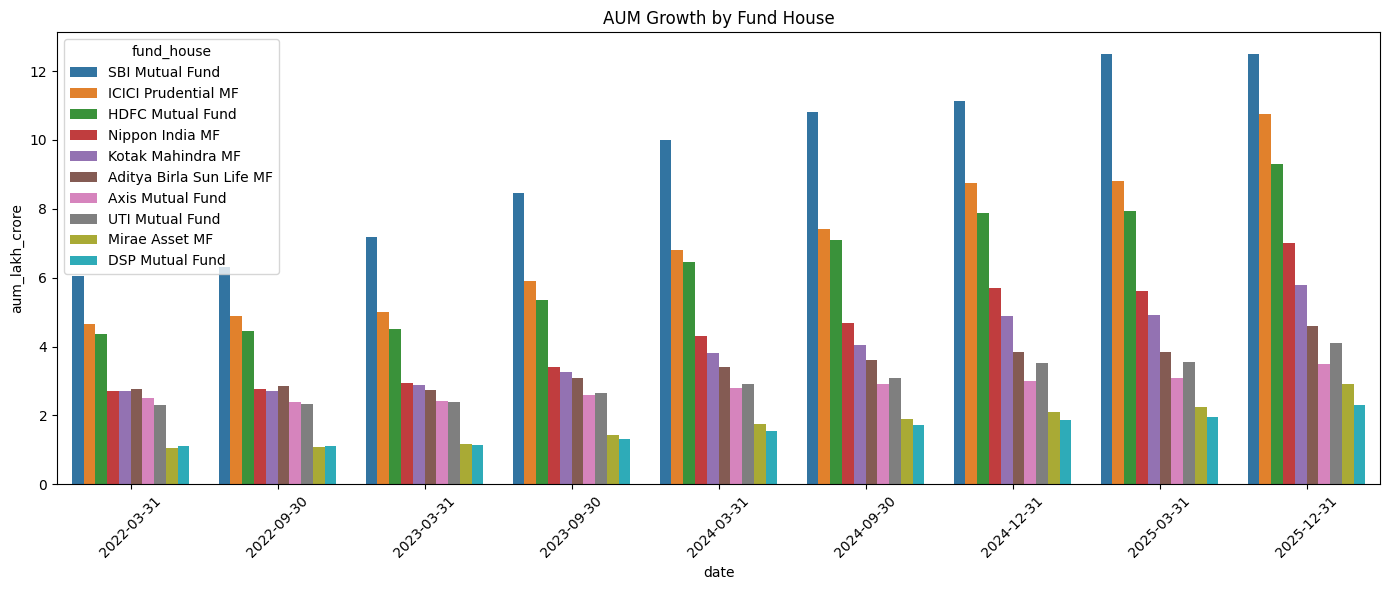

Chart saved


In [8]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/chart_02_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved")

# Insight 2

AUM across all major fund houses increased steadily from 2022 to 2025, reflecting continued growth in the Indian mutual fund industry.

(Refer Chart 02)

In [9]:
aum.groupby("fund_house")["aum_lakh_crore"] \
    .max() \
    .sort_values(ascending=False)

fund_house
SBI Mutual Fund             12.50
ICICI Prudential MF         10.74
HDFC Mutual Fund             9.30
Nippon India MF              7.00
Kotak Mahindra MF            5.80
Aditya Birla Sun Life MF     4.60
UTI Mutual Fund              4.10
Axis Mutual Fund             3.50
Mirae Asset MF               2.90
DSP Mutual Fund              2.30
Name: aum_lakh_crore, dtype: float64

In [10]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.show()

In [11]:
peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(peak)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [12]:
peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(peak)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [13]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [14]:
fig.write_image(
    "../reports/chart_03_sip_trend.png"
)

print("SIP Chart Saved")

TypeError: Type is not JSON serializable: Timestamp

In [15]:
peak_date = peak["month"].strftime("%Y-%m-%d")

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x=peak_date,
    y=peak["sip_inflow_crore"],
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [16]:
fig.write_image(
    "../reports/chart_03_sip_trend.png"
)

print("SIP Chart Saved Successfully")

SIP Chart Saved Successfully


In [17]:
type(peak["month"])

pandas.Timestamp

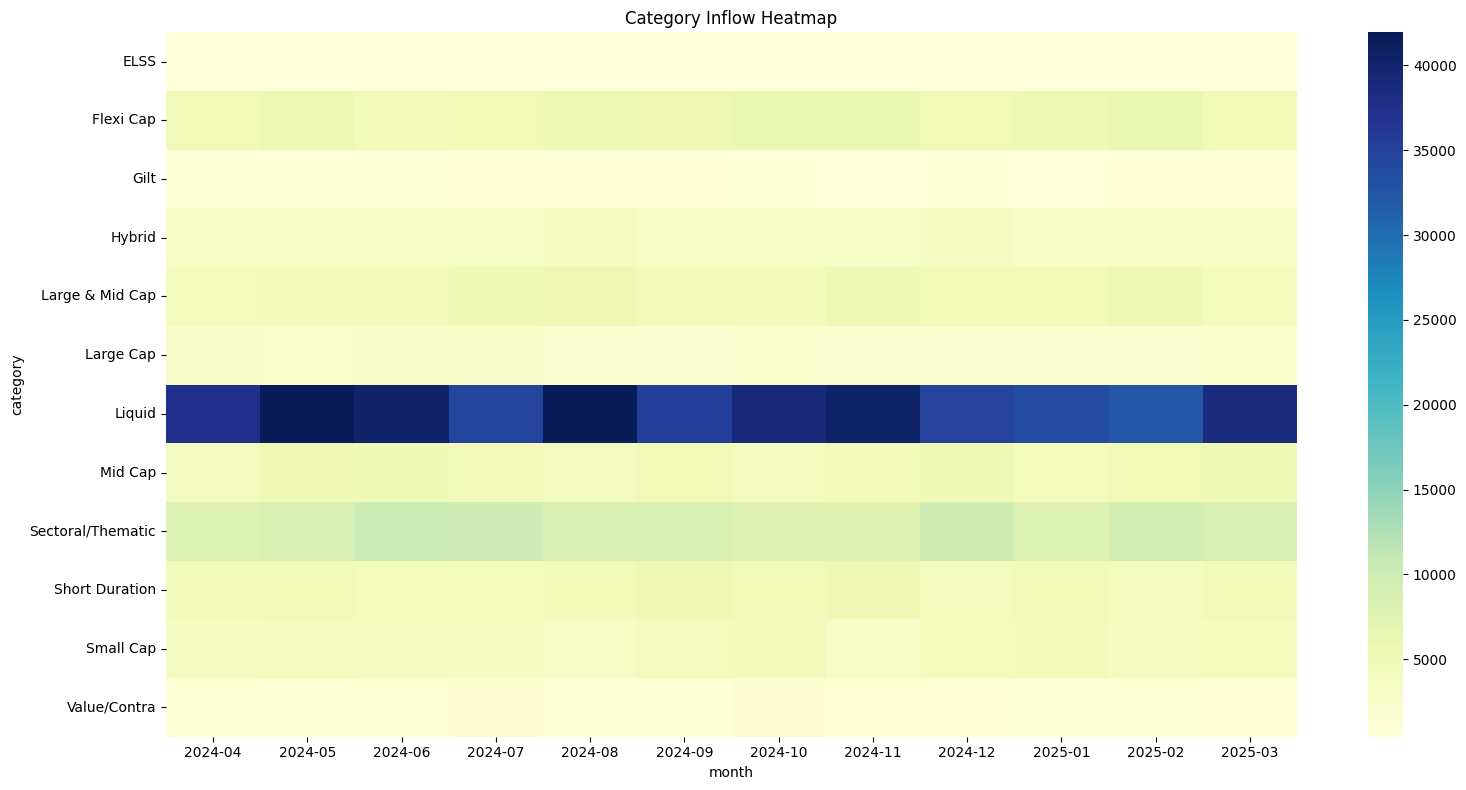

In [3]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/chart_04_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
print(category.shape)

(144, 3)


# Insight 4

Flexi Cap, Mid Cap and Small Cap categories consistently attracted higher net inflows than most other fund categories.

(Refer Chart 04)

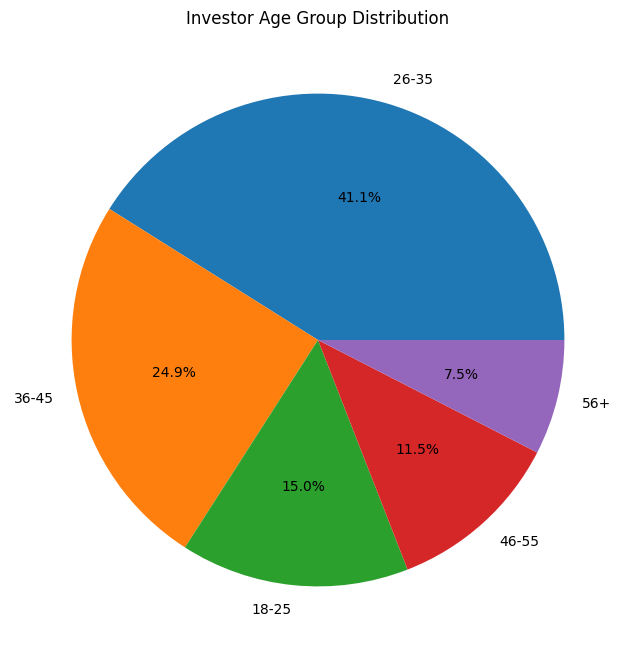

In [5]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.ylabel("")

plt.savefig(
    "../reports/chart_05_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight 5

The majority of investors belong to the working-age population, indicating strong participation from income-earning individuals.

(Refer Chart 05)

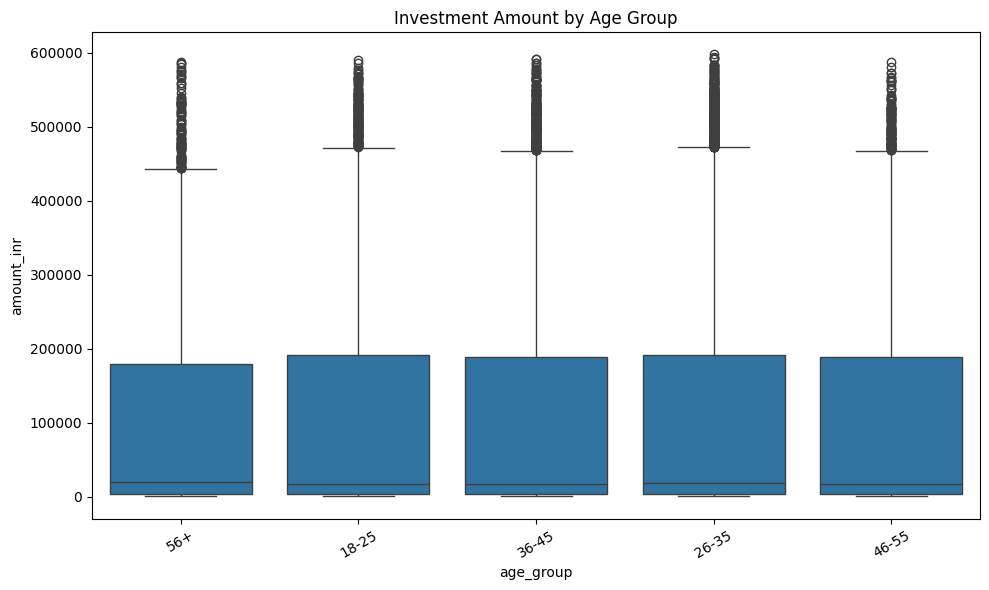

In [6]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../reports/chart_06_age_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight 6

Certain age groups exhibit higher median investment amounts and wider investment ranges compared to others.

(Refer Chart 06)

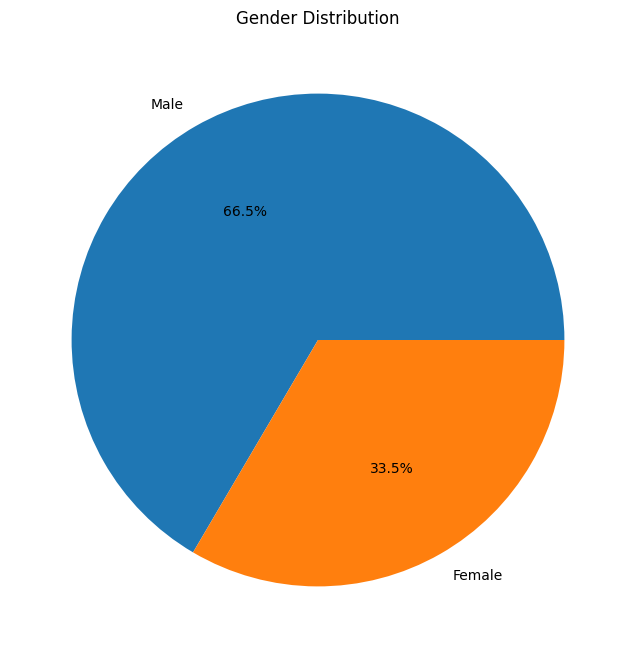

In [7]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.savefig(
    "../reports/chart_07_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight 7

Investor participation is distributed across genders, providing insight into market inclusivity.

(Refer Chart 07)

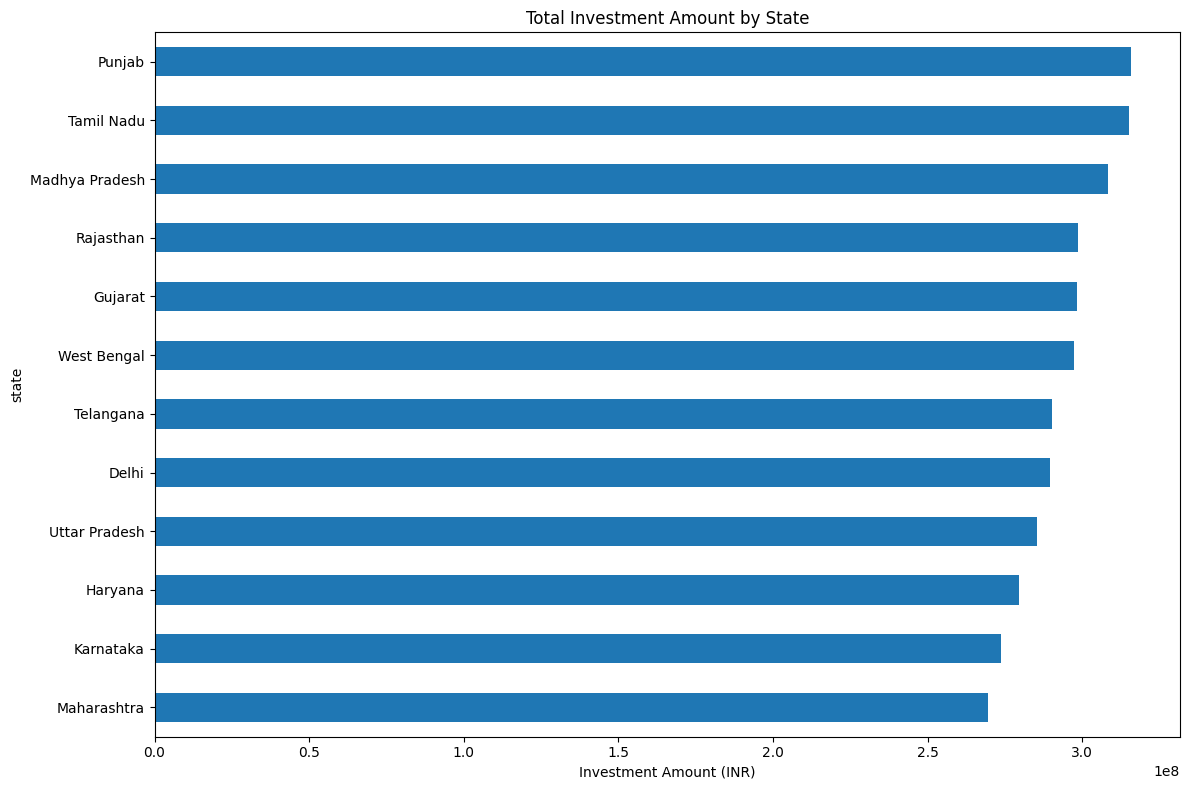

In [8]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_data.plot(
    kind="barh"
)

plt.title("Total Investment Amount by State")

plt.xlabel("Investment Amount (INR)")

plt.tight_layout()

plt.savefig(
    "../reports/chart_08_statewise_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight 8

A few states contribute a significantly larger share of total mutual fund investments compared to others.

(Refer Chart 08)

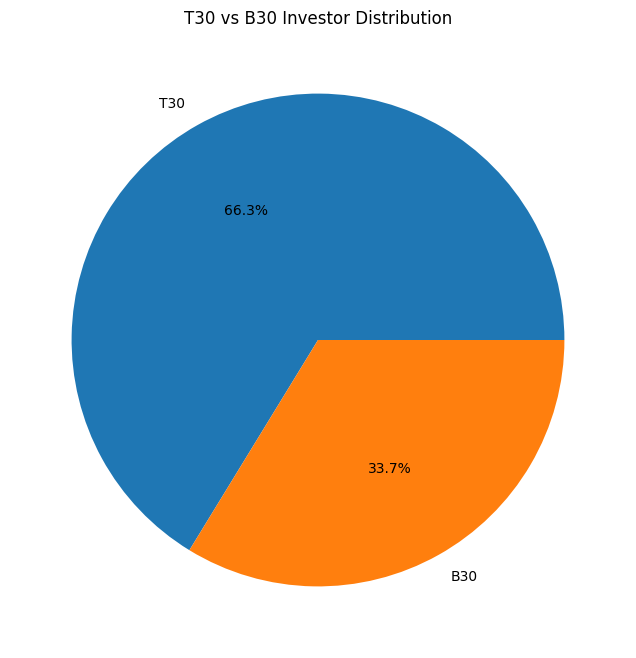

In [9]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.ylabel("")

plt.savefig(
    "../reports/chart_09_t30_b30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight 9

T30 cities continue to dominate mutual fund participation, although B30 cities show growing investor presence.

(Refer Chart 09)

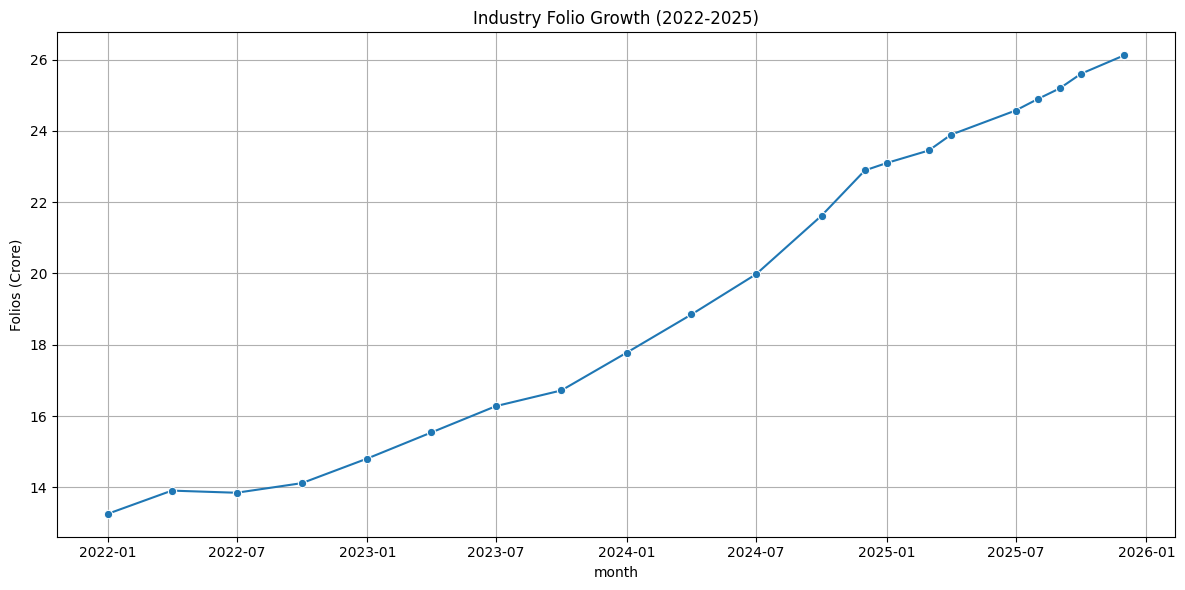

In [10]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folios,
    x="month",
    y="total_folios_crore",
    marker="o"
)

plt.title(
    "Industry Folio Growth (2022-2025)"
)

plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/chart_10_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight 10

Industry folio count increased substantially from 2022 to 2025, reflecting broader retail participation in mutual funds.

(Refer Chart 10)

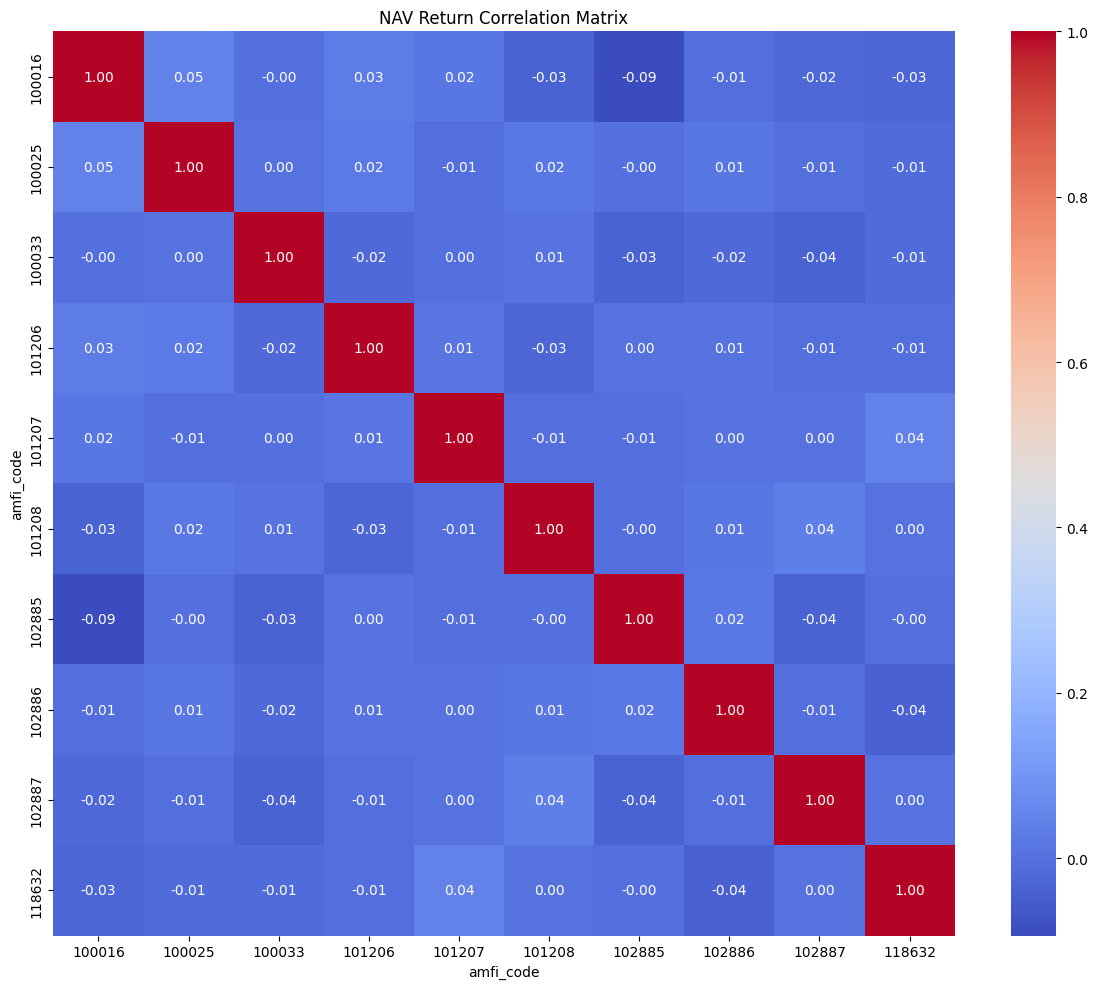

In [11]:
selected_funds = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot_nav = selected_funds.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "../reports/chart_11_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 11

Most large-cap mutual funds exhibit strong positive return correlation, reflecting common market exposure.

(Refer Chart 11)

In [12]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector_data,
    values="weight_pct",
    names="sector",
    hole=0.5,
    title="Sector Allocation Across Funds"
)

fig.show()

fig.write_html(
    "../reports/chart_12_sector_allocation.html"
)

## Insight 12

Financial Services and Technology sectors constitute a major portion of mutual fund portfolios.

(Refer Chart 12)

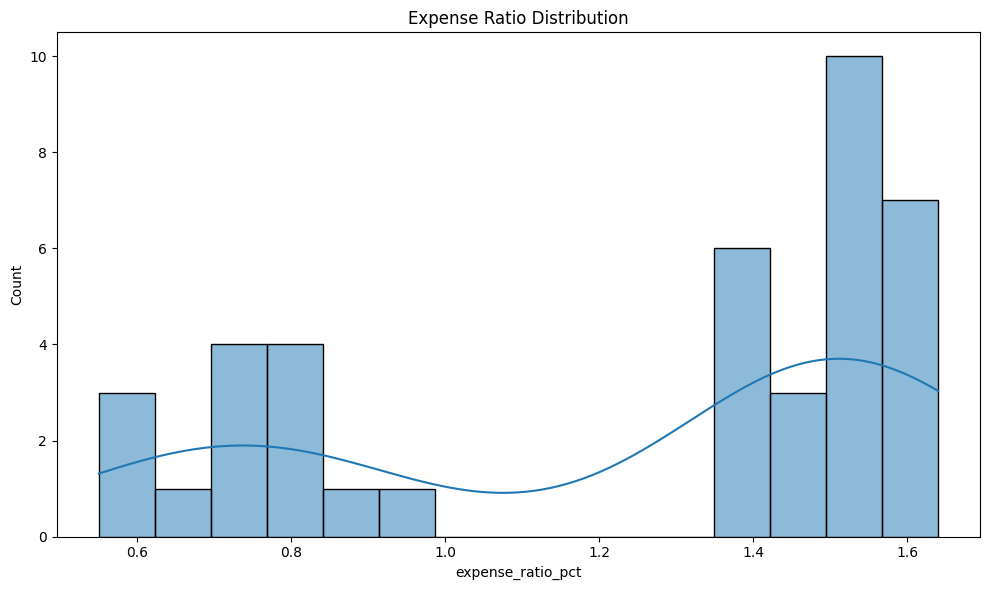

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title(
    "Expense Ratio Distribution"
)

plt.tight_layout()

plt.savefig(
    "../reports/chart_13_expense_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 13

Most schemes maintain expense ratios within a narrow range, indicating competitive pricing among AMCs.

(Refer Chart 13)

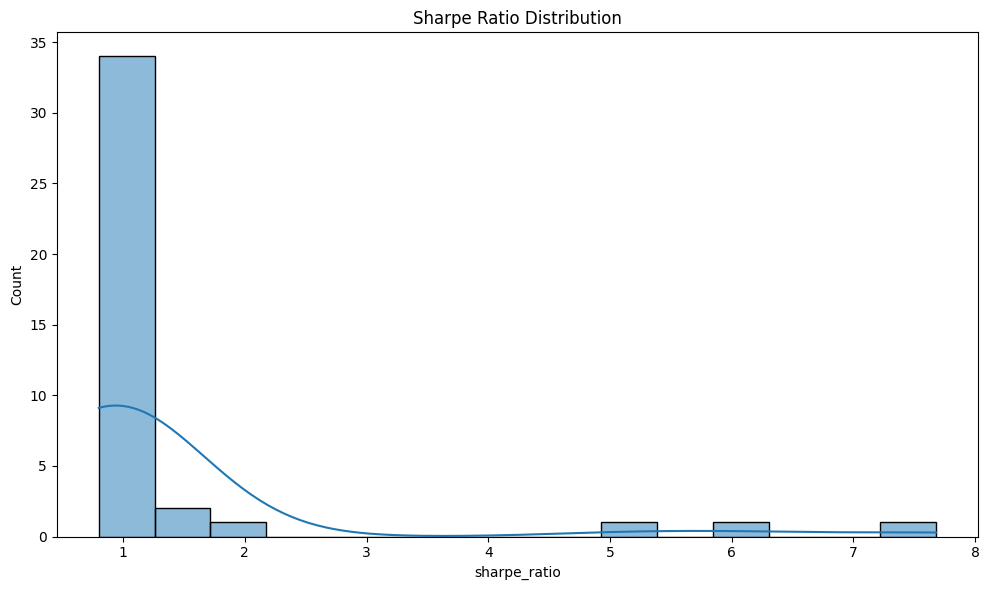

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["sharpe_ratio"],
    bins=15,
    kde=True
)

plt.title(
    "Sharpe Ratio Distribution"
)

plt.tight_layout()

plt.savefig(
    "../reports/chart_14_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 14

Several schemes demonstrate strong risk-adjusted returns as reflected by higher Sharpe ratios.

(Refer Chart 14)

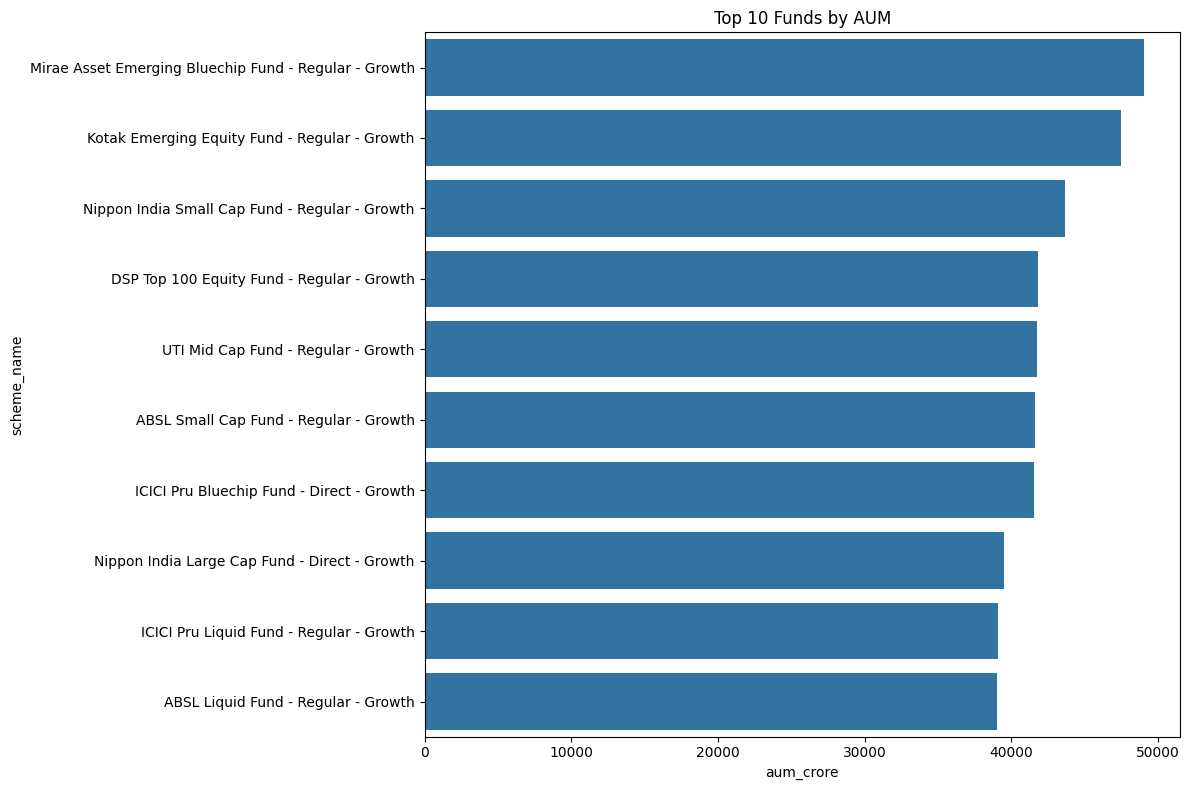

In [15]:
top_funds = (
    performance.sort_values(
        "aum_crore",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by AUM"
)

plt.tight_layout()

plt.savefig(
    "../reports/chart_15_top_funds_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 15

A small number of schemes account for a substantial share of total assets under management.

(Refer Chart 15)